In [5]:
import numpy as np
from prody import parsePDB
from typing import Tuple

# Constants
AA3_LIST = [
    'ALA', 'CYS', 'ASP', 'GLU', 'PHE', 'GLY', 'HIS',
    'ILE', 'LYS', 'LEU', 'MET', 'ASN', 'PRO', 'GLN',
    'ARG', 'SER', 'THR', 'VAL', 'TRP', 'TYR', 'UNK'
]
ATOM_TYPES = ['CA', 'CB']
AA3_TO_INDEX = {aa: i for i, aa in enumerate(AA3_LIST)}

SCAN_RADIUS = 5.0  # Å
VOXEL_SIZE = 2.0   # Å
GRID_SIZE = 7      # 7x7x7 voxel grid

def get_voxel_centers(center_coord: np.ndarray) -> np.ndarray:
    """Generate voxel center coordinates for the 7x7x7 grid centered at center_coord."""
    half_grid = GRID_SIZE // 2
    shifts = np.arange(-half_grid, half_grid + 1) * VOXEL_SIZE
    offsets = np.stack(np.meshgrid(shifts, shifts, shifts, indexing="ij"), axis=-1).reshape(-1, 3)
    return center_coord + offsets  # shape (343, 3)

def compute_atomic_distance_profile(pdb_path: str, mut_pos: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a voxel grid of shape (1, 7, 7, 7, 63) representing atomic closeness profiles
    and one-hot residue identity, and a mapping grid (1, 7, 7, 7) indicating closest residue index.

    Args:
        pdb_path: Path to AlphaFold PDB file.
        mut_pos: 1-based mutation position.

    Returns:
        feature_grid: shape (1, 7, 7, 7, 63)
        mapping_grid: shape (1, 7, 7, 7)
    """
    structure = parsePDB(pdb_path)
    atoms = structure.select('name CA CB')
    if atoms is None or len(atoms) == 0:
        raise ValueError("No CA or CB atoms found in structure.")

    coords = atoms.getCoords()
    names = atoms.getNames()
    resnames = atoms.getResnames()
    resnums = atoms.getResnums()

    # Identify mutation center (CA of the mutated residue)
    ca_indices = [i for i, name in enumerate(names) if name == 'CA']
    ca_resnums = resnums[ca_indices]
    ca_target_idx = np.where(ca_resnums == mut_pos)[0]
    if len(ca_target_idx) == 0:
        raise ValueError(f"Mutation site {mut_pos} not found in CA atoms.")
    center_coord = coords[ca_indices[ca_target_idx[0]]]

    # Step 2: Define voxel grid centers
    voxel_centers = get_voxel_centers(center_coord)  # shape (343, 3)

    # Step 3: Init output arrays
    feature_grid = np.zeros((GRID_SIZE ** 3, 63), dtype=np.float32)
    mapping_grid = np.full((GRID_SIZE ** 3,), -1, dtype=np.int32)

    # Step 4: Compute features for each voxel
    for vi, vcenter in enumerate(voxel_centers):
        # 4-1: Closeness (42 features)
        for atom_type_idx, atom_type in enumerate(ATOM_TYPES):
            for aa_idx, aa in enumerate(AA3_LIST):
                if atom_type == 'CB' and aa == 'GLY':
                    continue  # GLY has no CB atom
                mask = np.logical_and(np.char.equal(names, atom_type), np.char.equal(resnames, aa))
                if not np.any(mask):
                    continue
                aa_coords = coords[mask]
                dists = np.linalg.norm(aa_coords - vcenter, axis=1)
                within_r = dists[dists <= SCAN_RADIUS]
                if len(within_r) == 0:
                    continue
                min_d = np.min(within_r)
                closeness = 1.0 - (min_d / SCAN_RADIUS)
                feature_grid[vi, aa_idx + 21 * atom_type_idx] = closeness

        # 4-2: Closest residue mapping
        dists_all = np.linalg.norm(coords - vcenter, axis=1)
        min_idx = np.argmin(dists_all)
        closest_resnum = resnums[min_idx]
        mapping_grid[vi] = closest_resnum

        # 4-3: One-hot residue type
        closest_resname = resnames[min_idx]
        aa_index = AA3_TO_INDEX.get(closest_resname, 20)  # Use 'UNK'=20 if unknown
        feature_grid[vi, 42 + aa_index] = 1.0  # Append at index 42-62

    # Step 5: Reshape
    feature_grid = feature_grid.reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE, 63)
    mapping_grid = mapping_grid.reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE)

    return feature_grid[np.newaxis], mapping_grid[np.newaxis]  # Add batch dim


In [37]:
import pandas as pd
import os

# 📌 너가 주는 정보
tsv_path = r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\rhapsody2_sav_db_exactmatch_only.tsv"
pdb_dir = r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\alphafold_structures"

# ✅ 1. TSV 불러오기
df = pd.read_csv(tsv_path, sep="\t", header=None)
df.columns = ["UniProtID", "StructureFile", "MutPos", "WT", "Mut", "Label"]

# ✅ 2. 첫 번째 row 가져오기
row = df.iloc[0]
structure_file = row["StructureFile"]
mut_pos = int(row["MutPos"])  # 1-based 그대로 사용

# ✅ 3. PDB 경로 구성
pdb_path = os.path.join(pdb_dir, structure_file)

# ✅ 4. Voxelization 실행
feature_grid, mapping_grid = compute_atomic_distance_profile(pdb_path, mut_pos)

# ✅ 5. 결과 확인
print("Feature grid shape:", feature_grid.shape)   # (1, 7, 7, 7, 42)   
print("Mapping grid shape:", mapping_grid.shape)   # (1, 7, 7, 7)

# 예시로 중앙 voxel의 feature vector 출력
print("Central voxel feature (center of 7x7x7):")
print(feature_grid[0, 3, 3, 3])  # shape: (42,)
print("Central voxel maps to residue:", mapping_grid[0, 3, 3, 3])


@> 4377 atoms and 1 coordinate set(s) were parsed in 0.06s.


['ARG']
Feature grid shape: (1, 7, 7, 7, 63)
Mapping grid shape: (1, 7, 7, 7)
Central voxel feature (center of 7x7x7):
[0.         0.         0.         0.         0.         0.
 0.         0.22417206 0.         0.         0.         0.
 0.         0.         1.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.10130244 0.
 0.         0.         0.         0.         0.         0.6922485
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         1.         0.         0.         0.
 0.         0.         0.        ]
Central voxel maps to residue: 69


In [3]:
import numpy as np
from prody import parsePDB
from typing import Tuple

# Constants
AA3_LIST = [
    'ALA', 'CYS', 'ASP', 'GLU', 'PHE', 'GLY', 'HIS',
    'ILE', 'LYS', 'LEU', 'MET', 'ASN', 'PRO', 'GLN',
    'ARG', 'SER', 'THR', 'VAL', 'TRP', 'TYR', 'UNK'
]  # 20 aa + 'UNK' = 21
ATOM_TYPES = ['CA', 'CB']
AA3_TO_INDEX = {aa: i for i, aa in enumerate(AA3_LIST)}

SCAN_RADIUS = 5.0  # Å
VOXEL_SIZE = 2.0   # Å
GRID_SIZE = 7      # 7x7x7 voxel grid

def get_voxel_centers(center_coord: np.ndarray) -> np.ndarray:
    """Return (343, 3) absolute coordinates for 7x7x7 voxel centers around center_coord."""
    half = GRID_SIZE // 2  # 3
    shifts = (np.arange(-half, half + 1, dtype=np.float32) * VOXEL_SIZE)  # [-6, -4, -2, 0, 2, 4, 6]
    gx, gy, gz = np.meshgrid(shifts, shifts, shifts, indexing="ij")
    offsets = np.stack([gx, gy, gz], axis=-1).reshape(-1, 3)  # (343, 3)
    return center_coord.astype(np.float32) + offsets

def compute_atomic_distance_profile(pdb_path: str, mut_pos: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build voxel features identical to the original implementation:
      - 42 closeness channels: (atom_type in {CA, CB}) x (aa in AA3_LIST)
        (GLY-CB is effectively always 0 as GLY has no CB)
      - 21 one-hot channels: residue type of the nearest *atom* (CA or CB)
      - mapping_grid: nearest *atom* residue number (resnum)
    Returns:
      feature_grid: (1, 7, 7, 7, 63), mapping_grid: (1, 7, 7, 7)
    """
    # --- Load and select CA/CB atoms ---
    structure = parsePDB(pdb_path)
    atoms = structure.select('name CA CB')
    if atoms is None or len(atoms) == 0:
        raise ValueError("No CA or CB atoms found in structure.")

    # Pull arrays (ensure types; coords in float32 for speed/memory)
    coords   = atoms.getCoords().astype(np.float32)   # (N, 3)
    names    = atoms.getNames()                       # (N,)
    resnames = atoms.getResnames()                    # (N,)
    resnums  = atoms.getResnums().astype(np.int32)    # (N,)

    # --- Find mutation center: CA at residue 'mut_pos' ---
    # Same semantics as original (AlphaFold numbering assumed)
    ca_mask = (names == 'CA') & (resnums == mut_pos)

    if not np.any(ca_mask):
        raise ValueError(f"Mutation site {mut_pos} not found in CA atoms.")
    # If multiple (unlikely), take the first (original behavior equivalent)
    center_coord = coords[ca_mask][0]  # (3,)

    print(resnames[ca_mask])

    # --- Generate voxel centers: (343, 3) ---
    voxel_centers = get_voxel_centers(center_coord)  # (343, 3)
    V = voxel_centers.shape[0]                       # 343
    R2 = np.float32(SCAN_RADIUS * SCAN_RADIUS)

    # --- Init outputs: (V, 63) features + (V,) mapping ---
    feat_size = len(ATOM_TYPES) * len(AA3_LIST)  # 2 * 21 = 42
    feature_grid = np.zeros((V, 63), dtype=np.float32)     # 42 closeness + 21 one-hot
    mapping_grid = np.full((V,), -1, dtype=np.int32)

    # --- Precompute indices for each (atom_type, aa) once (speed-up) ---
    # GLY-CB will be empty (no CB), so it will stay zeros as in original
    idx_cache = {}
    for atom_type in ATOM_TYPES:
        for aa in AA3_LIST:
            if atom_type == 'CB' and aa == 'GLY':
                idx_cache[(atom_type, aa)] = np.empty((0,), dtype=np.int32)
            else:
                mask = (names == atom_type) & (resnames == aa)
                idx_cache[(atom_type, aa)] = np.where(mask)[0].astype(np.int32)

    # --- Vectorized nearest-atom search for mapping & one-hot (identical semantics) ---
    # Compute squared distances from all voxel centers to all atoms: (V, N)
    # Using broadcasting: (V,1,3) - (1,N,3) -> (V,N,3) -> sum over last axis.
    diff_all = voxel_centers[:, None, :] - coords[None, :, :]      # (V, N, 3)
    dist2_all = np.einsum('vna,vna->vn', diff_all, diff_all)       # (V, N)

    # nearest atom indices per voxel (argmin of squared distance == argmin of distance)
    nearest_atom_idx = np.argmin(dist2_all, axis=1).astype(np.int32)  # (V,)
    nearest_resnums  = resnums[nearest_atom_idx]                       # (V,)
    nearest_resnames = resnames[nearest_atom_idx]                      # (V,)

    # Fill mapping grid (resnum of nearest atom), identical to original
    mapping_grid[:] = nearest_resnums

    # Fill one-hot residue type of nearest atom (CA or CB). Keep UNK=20 as fallback.
    # Vectorized map of 3-letter -> index in AA3_LIST
    # (343 elements -> simple loop is fine; clarity > micro-optim here)
    for v in range(V):
        aa3 = nearest_resnames[v]
        aa_idx = AA3_TO_INDEX.get(aa3, 20)  # default UNK
        feature_grid[v, feat_size + aa_idx] = 1.0

    # --- Vectorized closeness per (atom_type, aa) across all voxels ---
    # For each channel column c, compute min distance within radius and convert to closeness
    for atom_type_idx, atom_type in enumerate(ATOM_TYPES):
        for aa_idx, aa in enumerate(AA3_LIST):
            col = aa_idx + 21 * atom_type_idx  # channel column for this (atom_type, aa)
            idxs = idx_cache[(atom_type, aa)]
            if idxs.size == 0:
                continue  # leave zeros (same as original)

            # Distances from all voxel centers to this subset of atoms: (V, K)
            sub_coords = coords[idxs]                                           # (K, 3)
            diff = voxel_centers[:, None, :] - sub_coords[None, :, :]           # (V, K, 3)
            dist2 = np.einsum('vka,vka->vk', diff, diff)                        # (V, K)

            # Apply radius filter (<= R), compute min distance within radius
            # If none within radius, leave 0 (as original)
            dist2_masked = np.where(dist2 <= R2, dist2, np.inf).astype(np.float32)  # (V, K)
            min_dist2 = np.min(dist2_masked, axis=1)                                # (V,)

            # closeness = 1 - (min_dist / r) where defined, else 0
            # Note: sqrt only where finite for identical numeric behavior
            valid = np.isfinite(min_dist2)
            closeness = np.zeros((V,), dtype=np.float32)
            if np.any(valid):
                closeness[valid] = 1.0 - (np.sqrt(min_dist2[valid]) / SCAN_RADIUS)

            feature_grid[:, col] = closeness

    # --- Reshape to (1, 7, 7, 7, 63) and (1, 7, 7, 7) ---
    feature_grid = feature_grid.reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE, 63)
    mapping_grid = mapping_grid.reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE)

    return feature_grid[None, ...], mapping_grid[None, ...]



In [5]:
import numpy as np
from prody import parsePDB
from typing import Tuple

# Constants
AA3_LIST = [
    'ALA', 'CYS', 'ASP', 'GLU', 'PHE', 'GLY', 'HIS',
    'ILE', 'LYS', 'LEU', 'MET', 'ASN', 'PRO', 'GLN',
    'ARG', 'SER', 'THR', 'VAL', 'TRP', 'TYR', 'UNK'
]  # 20 aa + 'UNK' = 21
ATOM_TYPES = ['CA', 'CB']
AA3_TO_INDEX = {aa: i for i, aa in enumerate(AA3_LIST)}

SCAN_RADIUS = 5.0  # Å
VOXEL_SIZE = 2.0   # Å
GRID_SIZE = 7      # 7x7x7 voxel grid

def get_voxel_centers(center_coord: np.ndarray) -> np.ndarray:
    half = GRID_SIZE // 2
    shifts = (np.arange(-half, half + 1, dtype=np.float32) * VOXEL_SIZE)
    gx, gy, gz = np.meshgrid(shifts, shifts, shifts, indexing="ij")
    offsets = np.stack([gx, gy, gz], axis=-1).reshape(-1, 3)
    return center_coord.astype(np.float32) + offsets

def compute_atomic_distance_profile(
    pdb_path: str,
    mut_pos: int,
    add_seqpos_features: bool = True
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      feature_grid: (1, 7, 7, 7, 63[+2]), mapping_grid: (1, 7, 7, 7)
    63ch = 42 closeness(CA/CB x 21) + 21 one-hot(CA-only 최근접 잔기)
    [+2ch] = Δpos 상대서열거리 (signed_norm, abs_norm)
    """
    # --- Load ---
    structure = parsePDB(pdb_path)
    atoms_all = structure.select('name CA CB')
    if atoms_all is None or len(atoms_all) == 0:
        raise ValueError("No CA or CB atoms found in structure.")

    coords_all   = atoms_all.getCoords().astype(np.float32)
    names_all    = atoms_all.getNames()
    resnames_all = atoms_all.getResnames()
    resnums_all  = atoms_all.getResnums().astype(np.int32)

    # --- Center at mut_pos CA ---
    ca_mask_mut = (names_all == 'CA') & (resnums_all == mut_pos)
    if not np.any(ca_mask_mut):
        raise ValueError(f"Mutation site {mut_pos} not found in CA atoms.")
    center_coord = coords_all[ca_mask_mut][0]

    voxel_centers = get_voxel_centers(center_coord)   # (343,3)
    V = voxel_centers.shape[0]
    R2 = np.float32(SCAN_RADIUS * SCAN_RADIUS)

    # --- Outputs ---
    base_feat_size = len(ATOM_TYPES) * len(AA3_LIST)  # 42
    extra = 2 if add_seqpos_features else 0
    total_feat = 63 + extra
    feature_grid = np.zeros((V, total_feat), dtype=np.float32)
    mapping_grid = np.full((V,), -1, dtype=np.int32)

    # --- Closeness index cache (CA/CB 모두) ---
    idx_cache = {}
    for atom_type in ATOM_TYPES:
        for aa in AA3_LIST:
            if atom_type == 'CB' and aa == 'GLY':
                idx_cache[(atom_type, aa)] = np.empty((0,), dtype=np.int32)
            else:
                mask = (names_all == atom_type) & (resnames_all == aa)
                idx_cache[(atom_type, aa)] = np.where(mask)[0].astype(np.int32)

    # --- CA-only 집합(최근접 잔기 판단용) ---
    ca_mask_all = (names_all == 'CA')
    coords_ca   = coords_all[ca_mask_all]
    resnames_ca = resnames_all[ca_mask_all]
    resnums_ca  = resnums_all[ca_mask_all]

    # 체인 길이 근사 (resnum 연속 가정 완화용: max-min+1)
    if resnums_ca.size == 0:
        raise ValueError("No CA atoms found.")
    L_est = max(1, int(resnums_ca.max() - resnums_ca.min() + 1))

    # --- CA-only 최근접 잔기 (원핫/매핑) ---
    diff_ca = voxel_centers[:, None, :] - coords_ca[None, :, :]      # (V,Nc,3)
    dist2_ca = np.einsum('vka,vka->vk', diff_ca, diff_ca)            # (V,Nc)
    nearest_ca_idx = dist2_ca.argmin(axis=1)                         # (V,)
    nearest_resnums_ca  = resnums_ca[nearest_ca_idx]                 # (V,)
    nearest_resnames_ca = resnames_ca[nearest_ca_idx]                # (V,)

    # mapping(resnum)
    mapping_grid[:] = nearest_resnums_ca

    # one-hot(21ch)
    for v in range(V):
        aa3 = nearest_resnames_ca[v]
        aa_idx = AA3_TO_INDEX.get(aa3, 20)
        feature_grid[v, base_feat_size + aa_idx] = 1.0  # channels 42..62

    # --- Δpos 2채널 추가(옵션) ---
    if add_seqpos_features:
        delta = nearest_resnums_ca.astype(np.int32) - int(mut_pos)
        signed_norm = np.clip(delta.astype(np.float32) / float(L_est), -1.0, 1.0)
        abs_norm = np.minimum(np.abs(signed_norm), 1.0)
        feature_grid[:, 63] = signed_norm
        feature_grid[:, 64] = abs_norm

    # --- Closeness(CA/CB 모두) 0..41 채우기 ---
    for atom_type_idx, atom_type in enumerate(ATOM_TYPES):
        for aa_idx, aa in enumerate(AA3_LIST):
            col = aa_idx + 21 * atom_type_idx  # 0..41
            idxs = idx_cache[(atom_type, aa)]
            if idxs.size == 0:
                continue
            sub_coords = coords_all[idxs]                                        # (K,3)
            diff = voxel_centers[:, None, :] - sub_coords[None, :, :]            # (V,K,3)
            dist2 = np.einsum('vka,vka->vk', diff, diff)                         # (V,K)
            dist2_masked = np.where(dist2 <= R2, dist2, np.inf).astype(np.float32)
            min_dist2 = np.min(dist2_masked, axis=1)                             # (V,)
            valid = np.isfinite(min_dist2)
            closeness = np.zeros((V,), dtype=np.float32)
            if np.any(valid):
                closeness[valid] = 1.0 - (np.sqrt(min_dist2[valid]) / SCAN_RADIUS)
            feature_grid[:, col] = closeness

    # --- Reshape ---
    feature_grid = feature_grid.reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE, total_feat)
    mapping_grid = mapping_grid.reshape(GRID_SIZE, GRID_SIZE, GRID_SIZE)

    return feature_grid[None, ...], mapping_grid[None, ...]

In [27]:
import pandas as pd
import os

# 📌 너가 주는 정보
tsv_path = r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\rhapsody2_sav_db_exactmatch_only.tsv"
pdb_dir = r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\alphafold_structures"

# ✅ 1. TSV 불러오기
df = pd.read_csv(tsv_path, sep="\t", header=None)
df.columns = ["UniProtID", "StructureFile", "MutPos", "WT", "Mut", "Label"]

# ✅ 2. 첫 번째 row 가져오기
row = df.iloc[3]
structure_file = row["StructureFile"]
mut_pos = int(row["MutPos"])  # 1-based 그대로 사용
print("WT in TSV:", row["WT"])

# ✅ 3. PDB 경로 구성
pdb_path = os.path.join(pdb_dir, structure_file)

# ✅ 4. Voxelization 실행
feature_grid, mapping_grid = compute_atomic_distance_profile(pdb_path, mut_pos)

# ✅ 5. 결과 확인
print("Feature grid shape:", feature_grid.shape)   # (1, 7, 7, 7, 42)   
print("Mapping grid shape:", mapping_grid.shape)   # (1, 7, 7, 7)

# 예시로 중앙 voxel의 feature vector 출력
print("Central voxel feature (center of 7x7x7):")
print(feature_grid[0, 3, 3, 3])  # shape: (42,)
print("Central voxel maps to residue:", mapping_grid[0, 3, 3, 3])


@> 8039 atoms and 1 coordinate set(s) were parsed in 0.11s.


WT in TSV: R
Feature grid shape: (1, 7, 7, 7, 65)
Mapping grid shape: (1, 7, 7, 7)
Central voxel feature (center of 7x7x7):
[0.         0.         0.         0.         0.         0.
 0.         0.23841006 0.         0.2357068  0.         0.
 0.         0.         1.         0.1297487  0.         0.
 0.         0.         0.         0.03064728 0.         0.
 0.         0.         0.         0.         0.03411072 0.
 0.09082639 0.         0.         0.         0.         0.69364244
 0.03078049 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         1.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
Central voxel maps to residue: 193


In [22]:
import pandas as pd
import os
import numpy as np

tsv_path = r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\rhapsody2_sav_db_exactmatch_only.tsv"
pdb_dir  = r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\alphafold_structures"

df = pd.read_csv(tsv_path, sep="\t", header=None,
                 names=["UniProtID","StructureFile","MutPos","WT","Mut","Label"])

row = df.iloc[2]
pdb_path = os.path.join(pdb_dir, row["StructureFile"])
mut_pos  = int(row["MutPos"])
wt1, mut1 = row["WT"], row["Mut"]

S, names = extract_struct_S(pdb_path, mut_pos, wt1, mut1)
print("S dim:", len(S))
print(dict(zip(names, S)))

@> 862 atoms and 1 coordinate set(s) were parsed in 0.01s.
@> Kirchhoff was built in 0.00s.


S dim: 21
{'plddt_center': 51.47, 'plddt_neigh_mean': 54.775, 'plddt_neigh_min': 48.66, 'plddt_neigh_max': 62.88, 'msf_center': 0.25, 'msf_neigh_mean': 0.25, 'lrco': 0.0088495575, 'd_volume': 113.3, 'd_hydropathy': -4.1, 'd_charge': 1.0, 'rsa_center': 0.0, 'rsa_neigh_mean': 0.0, 'ddg_fold': nan, 'ddg_bind': nan, 'sin_phi': 0.68791825, 'cos_phi': -0.7257882, 'sin_psi': 0.95262516, 'cos_psi': -0.30414695, 'residue_depth': 1.0, 'gly_switch': 1.0, 'pro_switch': 0.0}


# WSL 쉘
EVO="/home/kunny/EvoEF2/EvoEF2"
BASE=/mnt/c/Users/Kunny/Research/Dataset/Missense_Variant_dataset
INP=$BASE/alphafold_structures/AF-P15289-F1-model_v4.pdb
OUT=$BASE/evoef2_out_P15289

mkdir -p "$OUT/models"
cd "$OUT"
cp "$INP" ARSA.pdb


grep "^ATOM" ARSA.pdb | cut -c22 | sort -u
# 'A'만 나오면 OK. 아니면 알려줘 → 체인=A 리네임 스크립트 줄게.



In [23]:
# make_evoef2_lists.py
# 사용: py make_evoef2_lists.py
import os, csv

# === 사용자 경로 설정 ===
TSV_PATH = r"C:\Users\Kunny\Research\Project\BiConVarNet\ARSA\sample_data.tsv"
# EvoEF2 작업 폴더(WSL에서 사용 중인 폴더와 같은 곳을 지정하면 편함)
OUT_DIR  = r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\evoef2_out_P15289"

# 필터 조건 (원하면 전체를 만들려면 조건을 바꾸거나 None로 둠)
TARGET_UID = "P15289"           # ARSA만 추출
TARGET_PDB = "AF-P15289-F1-model_v4.pdb"  # 특정 구조만

os.makedirs(OUT_DIR, exist_ok=True)

mutlist_path = os.path.join(OUT_DIR, "mut_list_all.txt")          # EvoEF2 변이 리스트
mapping_path = os.path.join(OUT_DIR, "mutants_mapping.tsv")       # 참고용 매핑(모델링 후 매칭/디버깅 편함)

n = 0
with open(TSV_PATH, newline="", encoding="utf-8") as f, \
     open(mutlist_path, "w", encoding="ascii", newline="\n") as g, \
     open(mapping_path, "w", encoding="utf-8", newline="") as m:

    rdr = csv.DictReader(f, delimiter="\t")
    mw = csv.writer(m, delimiter="\t")
    mw.writerow(["UniProtID", "StructureFile", "MutPos", "WT", "Mut", "Label", "EvoEF2_mut_string"])

    for r in rdr:
        uid = r.get("UniProtID", "").strip()
        pdb = r.get("StructureFile", "").strip()
        if TARGET_UID and uid != TARGET_UID:
            continue
        if TARGET_PDB and pdb != TARGET_PDB:
            continue

        wt  = r.get("WT", "").strip().upper()
        mt  = r.get("Mut", "").strip().upper()
        pos = int(r.get("MutPos", "0"))

        # AlphaFold는 체인 A 가정
        evoef_mut = f"{wt}A{pos}{mt};"   # 예: GA123D;

        g.write(evoef_mut + "\n")

        mw.writerow([
            uid, pdb, pos, wt, mt, r.get("Label", ""), evoef_mut
        ])
        n += 1

print(f"[OK] 변이 {n}개를 '{mutlist_path}'에 작성했습니다.")
print(f"[OK] 매핑 파일: '{mapping_path}'")
print("\n다음 순서로 진행하세요 (WSL 쉘):")

[OK] 변이 349개를 'C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\evoef2_out_P15289\mut_list_all.txt'에 작성했습니다.
[OK] 매핑 파일: 'C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\evoef2_out_P15289\mutants_mapping.tsv'

다음 순서로 진행하세요 (WSL 쉘):


cd /mnt/c/Users/Kunny/Research/Dataset/Missense_Variant_dataset/evoef2_out_P15289
chmod +x run_evoef2_ddg_fold_perline.sh

EVO="/home/kunny/EvoEF2/EvoEF2" \
WT_PDB="ARSA.pdb" \
MUT_LIST="mut_list_all.txt" \
bash ./run_evoef2_ddg_fold_perline.sh

[진단] sample 중복: 0행  | ddg 중복: 2행


,mut,E_wt,E_mut,ddg_fold,EvoEF2_mut_string
168,GA259R;,-2493.94,-2464.72,29.22,GA259R
169,GA259R;,-2493.94,-2464.72,29.22,GA259R


[카운트] 원본: 348  | 조인 후(중복해결): 348

[상관]
raw ddg | Pearson r=-0.2604 (p=8.42e-07)  | Spearman ρ=-0.4189 (p=3.19e-16)
winsorized ddg | Pearson r=-0.2605 (p=8.35e-07)  | Spearman ρ=-0.4189 (p=3.22e-16)


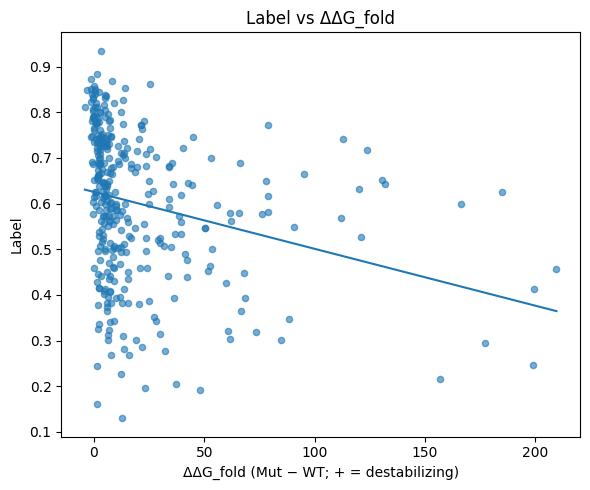

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# --- 경로 ---
sample_path = r"C:\Users\Kunny\Research\Project\BiConVarNet\ARSA\sample_data.tsv"
ddg_path    = r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\evoef2_out_P15289\ddg_fold.tsv"

# --- 로드 & 키 생성 ---
s = pd.read_csv(sample_path, sep="\t")
d = pd.read_csv(ddg_path,    sep="\t")

s["EvoEF2_mut_string"] = s["WT"].str.upper() + "A" + s["MutPos"].astype(str) + s["Mut"].str.upper()
d["EvoEF2_mut_string"] = d["mut"].str.replace(";", "", regex=False).str.strip().str.upper()

# --- 중복 진단 ---
s_dups = s[s.duplicated("EvoEF2_mut_string", keep=False)]
d_dups = d[d.duplicated("EvoEF2_mut_string", keep=False)]

print(f"[진단] sample 중복: {s_dups.shape[0]}행  | ddg 중복: {d_dups.shape[0]}행")
if not s_dups.empty:
    display(s_dups.head(10))
if not d_dups.empty:
    display(d_dups.head(10))

# --- ddg를 변이별로 집계(평균)해서 유일화 ---
d_uni = (d[["EvoEF2_mut_string","ddg_fold"]]
         .assign(ddg_fold=pd.to_numeric(d["ddg_fold"], errors="coerce"))
         .groupby("EvoEF2_mut_string", as_index=False)
         .agg(ddg_fold=("ddg_fold","mean")))

# --- 조인 & 정리 ---
m = (s.merge(d_uni, on="EvoEF2_mut_string", how="inner")
       .assign(Label=lambda x: pd.to_numeric(x["Label"], errors="coerce"))
       .dropna(subset=["Label","ddg_fold"]))

print(f"[카운트] 원본: {len(s)}  | 조인 후(중복해결): {len(m)}")

# --- 옵션: 1%/99% 윈저라이즈(아웃라이어 견고성) ---
q1, q99 = m["ddg_fold"].quantile([0.01, 0.99])
m["ddg_winz"] = m["ddg_fold"].clip(q1, q99)

# --- 상관계수 ---
def corr_report(x, y, tag):
    r, p = pearsonr(x, y)
    rs, ps = spearmanr(x, y)
    print(f"{tag} | Pearson r={r:.4f} (p={p:.2e})  | Spearman ρ={rs:.4f} (p={ps:.2e})")

print("\n[상관]")
corr_report(m["ddg_fold"].values, m["Label"].values, "raw ddg")
corr_report(m["ddg_winz"].values, m["Label"].values, "winsorized ddg")

# --- 산점도 + OLS 추세선 ---
X = m["ddg_fold"].values; Y = m["Label"].values
coef = np.polyfit(X, Y, 1)
xline = np.linspace(X.min(), X.max(), 200)
yline = coef[0]*xline + coef[1]

plt.figure(figsize=(6,5))
plt.scatter(X, Y, alpha=0.6, s=20)
plt.plot(xline, yline)
plt.xlabel("ΔΔG_fold (Mut − WT; + = destabilizing)")
plt.ylabel("Label")
plt.title("Label vs ΔΔG_fold")
plt.tight_layout()
plt.show()


[진단] sample 중복: 0행  | ddg 중복: 2행


,mut,E_wt,E_mut,ddg_fold,ddg_fold_z,EvoEF2_mut_string
168,GA259R;,-2493.94,-2464.72,29.22,0.261181,GA259R
169,GA259R;,-2493.94,-2464.72,29.22,0.261181,GA259R


[카운트] 원본: 348  | 조인 후(중복해결): 348

[상관]
raw ddg | Pearson r=-0.2604 (p=8.42e-07)  | Spearman ρ=-0.4189 (p=3.19e-16)
winsorized ddg | Pearson r=-0.2605 (p=8.35e-07)  | Spearman ρ=-0.4189 (p=3.22e-16)


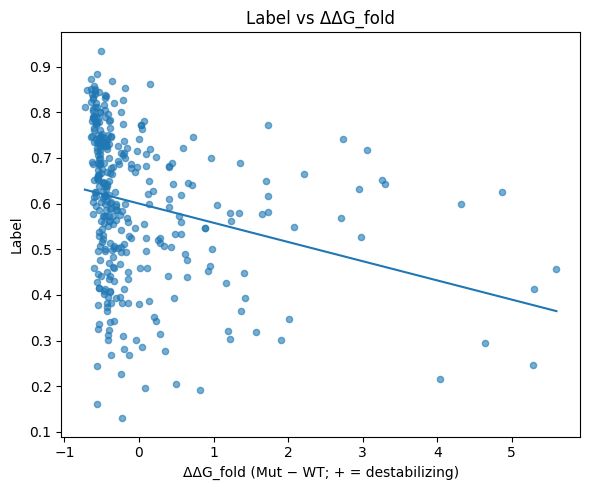

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# --- 경로 ---
sample_path = r"C:\Users\Kunny\Research\Project\BiConVarNet\ARSA\sample_data.tsv"
ddg_path    = r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\evoef2_out_P15289\ddg_fold_z.tsv"

# --- 로드 & 키 생성 ---
s = pd.read_csv(sample_path, sep="\t")
d = pd.read_csv(ddg_path,    sep="\t")

s["EvoEF2_mut_string"] = s["WT"].str.upper() + "A" + s["MutPos"].astype(str) + s["Mut"].str.upper()
d["EvoEF2_mut_string"] = d["mut"].str.replace(";", "", regex=False).str.strip().str.upper()

# --- 중복 진단 ---
s_dups = s[s.duplicated("EvoEF2_mut_string", keep=False)]
d_dups = d[d.duplicated("EvoEF2_mut_string", keep=False)]

print(f"[진단] sample 중복: {s_dups.shape[0]}행  | ddg 중복: {d_dups.shape[0]}행")
if not s_dups.empty:
    display(s_dups.head(10))
if not d_dups.empty:
    display(d_dups.head(10))

# --- ddg를 변이별로 집계(평균)해서 유일화 ---
d_uni = (d[["EvoEF2_mut_string","ddg_fold_z"]]
         .assign(ddg_fold_z=pd.to_numeric(d["ddg_fold_z"], errors="coerce"))
         .groupby("EvoEF2_mut_string", as_index=False)
         .agg(ddg_fold_z=("ddg_fold_z","mean")))

# --- 조인 & 정리 ---
m = (s.merge(d_uni, on="EvoEF2_mut_string", how="inner")
       .assign(Label=lambda x: pd.to_numeric(x["Label"], errors="coerce"))
       .dropna(subset=["Label","ddg_fold_z"]))

print(f"[카운트] 원본: {len(s)}  | 조인 후(중복해결): {len(m)}")

# --- 옵션: 1%/99% 윈저라이즈(아웃라이어 견고성) ---
q1, q99 = m["ddg_fold_z"].quantile([0.01, 0.99])
m["ddg_winz"] = m["ddg_fold_z"].clip(q1, q99)

# --- 상관계수 ---
def corr_report(x, y, tag):
    r, p = pearsonr(x, y)
    rs, ps = spearmanr(x, y)
    print(f"{tag} | Pearson r={r:.4f} (p={p:.2e})  | Spearman ρ={rs:.4f} (p={ps:.2e})")

print("\n[상관]")
corr_report(m["ddg_fold_z"].values, m["Label"].values, "raw ddg")
corr_report(m["ddg_winz"].values, m["Label"].values, "winsorized ddg")

# --- 산점도 + OLS 추세선 ---
X = m["ddg_fold_z"].values; Y = m["Label"].values
coef = np.polyfit(X, Y, 1)
xline = np.linspace(X.min(), X.max(), 200)
yline = coef[0]*xline + coef[1]

plt.figure(figsize=(6,5))
plt.scatter(X, Y, alpha=0.6, s=20)
plt.plot(xline, yline)
plt.xlabel("ΔΔG_fold (Mut − WT; + = destabilizing)")
plt.ylabel("Label")
plt.title("Label vs ΔΔG_fold")
plt.tight_layout()
plt.show()


In [54]:
import os
import numpy as np
import prody as pr

AA1_TO_AA3 = {'A':'ALA','C':'CYS','D':'ASP','E':'GLU','F':'PHE','G':'GLY','H':'HIS','I':'ILE',
              'K':'LYS','L':'LEU','M':'MET','N':'ASN','P':'PRO','Q':'GLN','R':'ARG','S':'SER',
              'T':'THR','V':'VAL','W':'TRP','Y':'TYR'} # 표준 1→3 letter 매핑. 문제 없음.
VOL = {'ALA':88.6,'CYS':108.5,'ASP':111.1,'GLU':138.4,'PHE':189.9,'GLY':60.1,'HIS':153.2,'ILE':166.7,
       'LYS':168.6,'LEU':166.7,'MET':162.9,'ASN':114.1,'PRO':112.7,'GLN':143.8,'ARG':173.4,'SER':89.0,
       'THR':116.1,'VAL':140.0,'TRP':227.8,'TYR':193.6} # 부피(Å³) 값들은 널리 쓰이는 표로, IMGT 레퍼런스에 같은 숫자
HYD = {'ALA':1.8,'CYS':2.5,'ASP':-3.5,'GLU':-3.5,'PHE':2.8,'GLY':-0.4,'HIS':-3.2,'ILE':4.5,
       'LYS':-3.9,'LEU':3.8,'MET':1.9,'ASN':-3.5,'PRO':-1.6,'GLN':-3.5,'ARG':-4.5,'SER':-0.8,
       'THR':-0.7,'VAL':4.2,'TRP':-0.9,'TYR':-1.3} # Kyte–Doolittle hydropathy 지수 그대로(예: ILE 4.5, ARG −4.5). 표준 값과 일치 (IMGT)
CHG = {'ASP':-1,'GLU':-1,'LYS':+1,'ARG':+1,'HIS':0} # HIS 0?
MAX_ASA = {'ALA':129.0,'ARG':274.0,'ASN':195.0,'ASP':193.0,'CYS':167.0,'GLN':225.0,'GLU':223.0,'GLY':104.0,
           'HIS':224.0,'ILE':197.0,'LEU':201.0,'LYS':236.0,'MET':224.0,'PHE':240.0,'PRO':159.0,'SER':155.0,
           'THR':172.0,'TRP':285.0,'TYR':263.0,'VAL':174.0} # “최대 용매 접근면적” 정상화 값, RSA 계산 표준으로 가장 많이 인용되는 스케일 중 하나

def _dihedral(p0,p1,p2,p3):
    b0 = p0 - p1; b1 = p2 - p1; b2 = p3 - p2
    b1 = b1 / (np.linalg.norm(b1) + 1e-8)
    v = b0 - np.dot(b0,b1)*b1
    w = b2 - np.dot(b2,b1)*b1
    x = np.dot(v,w); y = np.dot(np.cross(b1,v), w)
    return np.arctan2(y,x)

def _delta_physchem(wt3, mut3):
    d_vol = VOL.get(mut3, 150.0) - VOL.get(wt3, 150.0)
    d_hyd = HYD.get(mut3, 0.0)   - HYD.get(wt3, 0.0)
    d_chg = CHG.get(mut3, 0)     - CHG.get(wt3, 0)

    return float(d_vol), float(d_hyd), float(d_chg)

def _rsa_with_biopython(pdb_path):
    try:
        from Bio.PDB import PDBParser, ShrakeRupley
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure('x', pdb_path)
        sr = ShrakeRupley()
        sr.compute(structure, level='R')
        rsa = {}
        for model in structure:
            for chain in model:
                cid = chain.id
                for res in chain:
                    if res.id[0] != ' ':  # skip HETATM/WAT
                        continue
                    resname = res.get_resname().upper()
                    asa = float(res.xtra.get('EXP_ASA', 0.0))
                    maxasa = MAX_ASA.get(resname)
                    if maxasa:
                        rsa[(cid, int(res.id[1]))] = min(max(asa / maxasa, 0.0), 1.0)
        return rsa
    except Exception:
        return None

def load_ddg_map(tsv_path: str, key_col="mut", value_col="ddg_fold") -> dict[str, float]:
    """
    ddg_fold.tsv를 읽어 변이키 -> 값 맵 생성.
    - key 예: 'IA23V;'  (세미콜론 포함)
    - 중복 키가 있으면 평균값으로 집계
    """
    df = pd.read_csv(tsv_path, sep="\t", dtype=str)
    if key_col not in df or value_col not in df:
        raise ValueError(f"columns '{key_col}', '{value_col}' not found in {tsv_path}")
    df = df[[key_col, value_col]].copy()
    df[key_col] = df[key_col].str.strip().str.upper()
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=[value_col])
    g = df.groupby(key_col, as_index=True)[value_col].mean()
    ddg = g.to_dict()
    # 키 편의상 세미콜론 제거 버전도 함께 매핑
    for k, v in list(ddg.items()):
        k2 = k.rstrip(";")
        ddg.setdefault(k2, v)
    return ddg

def _evoef2_key(wt1: str, pos: int, mut1: str, chain_id: str = "A", with_semicolon: bool = True) -> str:
    k = f"{wt1.upper()}{chain_id}{int(pos)}{mut1.upper()}"
    return k + ";" if with_semicolon else k

def extract_struct_S(
    pdb_path: str, mut_pos: int, wt1: str, mut1: str,
    neigh_r: float = 8.0, chain_id: str = 'A',
    ddg_map_fold: dict[str, float] | None = None,
    ddg_map_bind: dict[str, float] | None = None
):

    wt3 = AA1_TO_AA3[wt1.upper()]
    mut3 = AA1_TO_AA3[mut1.upper()]

    st_all = pr.parsePDB(pdb_path)
    ca = st_all.select(f'protein and chain {chain_id} and name CA') # ProDy로 PDB 전체를 파싱, 체인 A의 알파탄소(CA)만 추출
    if ca is None:
        raise ValueError(f"No CA atoms found for chain {chain_id}.")

    ca_coords   = ca.getCoords().astype(np.float32) # 각 ca의 3d 좌표
    ca_resnums  = ca.getResnums().astype(int) # 잔기 번호
    betas       = ca.getBetas().astype(np.float32) # pLDDT (0-100)

    hit = np.where(ca_resnums == mut_pos)[0] # 변이 중심 잔기 찾기
    if hit.size == 0:
        raise ValueError(f"mut_pos {mut_pos} not found in chain {chain_id}.")
    ci = int(hit[0]); cpos = ca_coords[ci] # 변이 위치(mut_pos)와 같은 resnum을 가진 Cα 인덱스 ci를 찾고, 그 좌표 cpos를 잡음.

    d_ca = np.linalg.norm(ca_coords - cpos, axis=1) # 각 Cα 좌표에서 중심 Cα 좌표 cpos를 뺀 벡터들의 길이를 구해서, 중심으로부터의 유클리드 거리(Å) 배열을 만든 거
    neigh_idx = np.where(d_ca <= neigh_r)[0]
    neigh_idx = neigh_idx[neigh_idx != ci]   # 중심 Cα와의 유클리드 거리로 반경 8Å 이웃을 구하고, 자기 자신은 제외

    # 1) pLDDT
    plddt_c = float(betas[ci]) # 센터: 해당 위치 pLDDT (betas[ci])
    if neigh_idx.size: # 주변 평균/최소/최대: 반경 8Å 내 이웃들만 대상으로 계산
        nb = betas[neigh_idx]
        plddt_mean, plddt_min, plddt_max = float(nb.mean()), float(nb.min()), float(nb.max())
    else:
        plddt_mean = plddt_min = plddt_max = plddt_c

    # 2) GNM-MSF
    try:
        from prody import GNM, calcSqFlucts
        gnm = GNM('gnm')
        gnm.buildKirchhoff(ca, cutoff=10.0) # Kirchhoff(접촉 그래프) 만들기
        
        gnm.calcModes()  # 고유값 / 고유벡터 계산
        msf = calcSqFlucts(gnm[:]).astype(np.float32) # 각 잔기의 MSF 구하기
    except Exception:
        deg = max((d_ca <= 10.0).sum() - 1, 1)
        msf = np.ones_like(d_ca, dtype=np.float32) * (1.0 / deg)
    msf_c    = float(msf[ci]) # 중심 잔기 값
    msf_mean = float(msf[neigh_idx].mean()) if neigh_idx.size else msf_c # 반경 8 Å 이웃(센터 제외)의 평균

    # 3) LRCO
    js = np.where(d_ca <= 8.0)[0]
    js = js[js != ci] # 접촉 기준 8Å 내부의 이웃 집합 js를 사용

    prot_len = int(ca_resnums.max())
    lrco = float(np.abs(ca_resnums[js] - ca_resnums[ci]).mean() / max(prot_len,1)) if js.size else 0.0 # 각 이웃 j에 대해 서열번호 차 |resnum_j − resnum_i|를 구해 평균.

    # 4) Δ물성
    d_vol, d_hyd, d_chg = _delta_physchem(wt3, mut3)

    # 5) RSA
    rsa_center = np.nan
    rsa_mean = np.nan
    rsa_map = _rsa_with_biopython(pdb_path)

    if rsa_map is not None:
        chain_ids = ca.getChids()
        center_key = (chain_ids[ci], ca_resnums[ci])
        rsa_center = float(rsa_map.get(center_key, np.nan))
        if neigh_idx.size:
            neigh_keys = [(chain_ids[k], ca_resnums[k]) for k in neigh_idx]
            nv = [rsa_map.get(k, np.nan) for k in neigh_keys]
            nv = np.array([v for v in nv if not np.isnan(v)], dtype=np.float32)
            rsa_mean = float(nv.mean()) if nv.size else rsa_center
        else:
            rsa_mean = rsa_center
    else:
        local_density = (d_ca <= 6.0).sum() - 1
        rsa_center = float(1.0 / (1.0 + max(local_density,0)/10.0))
        rsa_mean   = rsa_center

    # 6) Energetics: ddg_fold/ddg_bind 맵에서 채우기
    ddg_fold = np.nan
    # ddg_bind = np.nan
    if ddg_map_fold is not None:
        k1 = _evoef2_key(wt1, mut_pos, mut1, chain_id, with_semicolon=True)
        k2 = k1.rstrip(";")
        ddg_fold = float(ddg_map_fold.get(k1, ddg_map_fold.get(k2, np.nan)))
    # if ddg_map_bind is not None:
    #     k1 = _evoef2_key(wt1, mut_pos, mut1, chain_id, with_semicolon=True)
    #     k2 = k1.rstrip(";")
        # ddg_bind = float(ddg_map_bind.get(k1, ddg_map_bind.get(k2, np.nan)))

    # 7) Backbone torsion
    def _pick(name, resnum):
        sel = st_all.select(f"protein and chain {chain_id} and resnum {resnum} and name {name}")
        return sel.getCoords()[0] if (sel is not None and sel.numAtoms()>0) else None
    pN   = _pick('N',  mut_pos)
    pCA  = _pick('CA', mut_pos)
    pC   = _pick('C',  mut_pos)
    pCm1 = _pick('C',  mut_pos - 1)
    pNp1 = _pick('N',  mut_pos + 1)
    phi = psi = 0.0
    if pN is not None and pCA is not None and pC is not None:
        if pCm1 is not None: phi = float(_dihedral(pCm1, pN, pCA, pC))
        if pNp1 is not None: psi = float(_dihedral(pN, pCA, pC, pNp1))
    sin_phi, cos_phi = np.sin(phi), np.cos(phi)
    sin_psi, cos_psi = np.sin(psi), np.cos(psi)

    # # 8) Residue depth
    # res_depth = float(1.0 - rsa_center) if not np.isnan(rsa_center) else np.nan

    # 9) Gly/Pro
    gly_switch = 1.0 if (AA1_TO_AA3[wt1.upper()]=='GLY') ^ (AA1_TO_AA3[mut1.upper()]=='GLY') else 0.0
    pro_switch = 1.0 if (AA1_TO_AA3[wt1.upper()]=='PRO') ^ (AA1_TO_AA3[mut1.upper()]=='PRO') else 0.0

    S = np.array([
        plddt_c, plddt_mean, plddt_min, plddt_max,
        msf_c, msf_mean,
        lrco,
        d_vol, d_hyd, d_chg,
        rsa_center, rsa_mean,
        ddg_fold,
        sin_phi, cos_phi, sin_psi, cos_psi,
        gly_switch, pro_switch
    ], dtype=np.float32)

    names = [
        "plddt_center","plddt_neigh_mean","plddt_neigh_min","plddt_neigh_max",
        "msf_center","msf_neigh_mean",
        "lrco",
        "d_volume","d_hydropathy","d_charge",
        "rsa_center","rsa_neigh_mean",
        "ddg_fold",
        "sin_phi","cos_phi","sin_psi","cos_psi",
        "gly_switch","pro_switch"
    ]
    return S, names

In [55]:
ddg_fold_map = load_ddg_map(
    r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\evoef2_out_P15289\ddg_fold.tsv",
    key_col="mut", value_col="ddg_fold"
)

In [66]:
ddg_fold_map

{'AA108T;': 23.61,
 'AA133D;': -0.04,
 'AA165S;': -1.55,
 'AA165V;': 2.45,
 'AA183S;': -0.99,
 'AA189V;': 16.96,
 'AA199S;': 0.08,
 'AA199V;': 1.98,
 'AA205D;': 0.2,
 'AA205T;': 2.39,
 'AA212D;': 60.61,
 'AA212P;': 33.84,
 'AA212T;': 18.43,
 'AA212V;': 28.05,
 'AA224V;': 21.75,
 'AA314D;': -0.25,
 'AA314T;': 5.98,
 'AA323T;': -0.81,
 'AA342D;': 4.4,
 'AA404S;': 0.01,
 'AA416T;': 1.04,
 'AA422V;': 1.74,
 'AA455T;': 7.19,
 'AA464V;': 1.83,
 'AA468T;': 1.77,
 'AA469G;': 0.98,
 'AA478V;': 5.69,
 'AA484T;': 1.47,
 'AA75P;': 29.84,
 'CA156F;': 42.8,
 'CA156R;': 45.06,
 'CA172R;': 78.92,
 'CA294Y;': 2.65,
 'CA488R;': 112.77,
 'CA489G;': 12.59,
 'CA493F;': 33.55,
 'DA152H;': 18.77,
 'DA152N;': 1.24,
 'DA169N;': 3.41,
 'DA169Y;': 3.35,
 'DA211N;': 1.95,
 'DA255E;': 76.24,
 'DA255H;': 78.04,
 'DA255N;': 11.1,
 'DA281E;': 52.59,
 'DA281N;': 53.27,
 'DA29E;': 39.4,
 'DA29N;': 11.6,
 'DA30H;': 23.89,
 'DA335V;': 13.56,
 'DA354V;': 11.28,
 'DA357N;': 0.83,
 'DA357Y;': 65.71,
 'DA381E;': 5.31,
 'DA41

In [65]:
S, names = extract_struct_S(
    pdb_path=r"C:\Users\Kunny\Research\Dataset\Missense_Variant_dataset\alphafold_structures\AF-P15289-F1-model_v4.pdb",
    mut_pos=30, wt1="H", mut1="H", chain_id="A",
    ddg_map_fold=ddg_fold_map  # ← 여기서 Energetics 채워짐
)

S

@> 3770 atoms and 1 coordinate set(s) were parsed in 0.05s.
@> Kirchhoff was built in 0.02s.


array([9.8580002e+01, 9.8817993e+01, 9.8699997e+01, 9.8910004e+01,
       3.5714287e-02, 3.5714287e-02, 3.4845495e-01, 0.0000000e+00,
       0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
                 nan, 8.2913727e-01, 5.5904508e-01, 5.2514380e-01,
       8.5101354e-01, 0.0000000e+00, 0.0000000e+00], dtype=float32)